In [1]:
import pandas as pd
import numpy as np  
import xgboost as xgb
import optuna
from optuna_integration import XGBoostPruningCallback
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import shap
from dotenv import load_dotenv
import os
import joblib
from pathlib import Path

# Establish Country & Pollutant

In [2]:
load_dotenv()

True

In [3]:
POLLUTANT = "O3"

In [4]:
COUNTRY_CODE = os.getenv("COUNTRY_CODE")   
RESULTS_SAVE_FOLDER = os.getenv("RESULTS_SAVE_FOLDER")

In [5]:
# reading in data
base_path = os.getenv("BASE_DATA_PATH")
file_name = f"{COUNTRY_CODE}_{POLLUTANT}_Daily_Cleaned.parquet"
file_path = os.path.join(base_path, file_name)

In [6]:
# saving results
RUN_ID = f"{COUNTRY_CODE}_{POLLUTANT}"

output_dir = Path(RESULTS_SAVE_FOLDER) / f"Results_{RUN_ID}"
output_dir.mkdir(parents=True, exist_ok=True)

In [7]:
# saving model
model_filename = output_dir / f"xgboost_model_{COUNTRY_CODE}_{POLLUTANT}.pkl"

In [8]:
def log_stat(name, value): # save statistics as a test file
    with open(output_dir / "data_processing_log.txt", "a") as f:
        f.write(f"{name}: {value}\n")

with open(output_dir / "data_processing_log.txt", "w") as f: # clear log if it exists to start fresh
    f.write(f"Processing Log for {RUN_ID}\n")

In [9]:
df = pd.read_parquet(file_path, engine = 'pyarrow')

In [10]:
df.head(10)

,Samplingpoint,Start,Value
0,IE/SPO.IE.IE0001RSample1_7,2013-01-01,92.855797
1,IE/SPO.IE.IE0001RSample1_7,2013-01-02,76.622222
2,IE/SPO.IE.IE0001RSample1_7,2013-01-03,73.370833
3,IE/SPO.IE.IE0001RSample1_7,2013-01-04,77.793750
4,IE/SPO.IE.IE0001RSample1_7,2013-01-05,78.381250
5,IE/SPO.IE.IE0001RSample1_7,2013-01-06,81.093750
6,IE/SPO.IE.IE0001RSample1_7,2013-01-07,83.491667
7,IE/SPO.IE.IE0001RSample1_7,2013-01-08,67.029167
8,IE/SPO.IE.IE0001RSample1_7,2013-01-09,60.150000
9,IE/SPO.IE.IE0001RSample1_7,2013-01-10,79.222917


# Machine Learning Preperation - Feature Extraction & Dropping NaN

In [11]:
df['Start'] = pd.to_datetime(df['Start']) 
df = df.sort_values(by=['Samplingpoint', 'Start']).reset_index(drop=True) # sorting by station and start(date) and resetting index

df['Samplingpoint'] = df['Samplingpoint'].astype('category') # set as a category to use as category feature (can avpid using pd.getdummies onehotencoding and creating more columns), faster processing and less memory usage

In [12]:
# Extracting time based features
df['DayOfWeek'] = df['Start'].dt.dayofweek
df['Month'] = df['Start'].dt.month
df['DayOfYear'] = df['Start'].dt.dayofyear
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

In [13]:
df['Lag_1'] = df.groupby('Samplingpoint')['Value'].shift(1) 
df['Lag_7'] = df.groupby('Samplingpoint')['Value'].shift(7) 

In [14]:
df = df.set_index('Start') # Need index to be the 'Start'(date) column for rolling with time-based windows to work properly

df['Rolling_Mean_7D'] = df.groupby('Samplingpoint')['Value'].transform(
    lambda x: x.rolling('7D', min_periods=4).mean() # 7d creates rolling window of 7 calendar days instead of last 7 rows
)
df = df.reset_index()

In [15]:
df['Target'] = df.groupby('Samplingpoint')['Value'].shift(-1) # Target (y), shfts value back by 1 on the indexlevel, to get the next day today

In [16]:
print(f"Data shape after Feature Engineering {df.shape}")
df.head(10)

Data shape after Feature Engineering (69014, 11)


,Start,Samplingpoint,Value,DayOfWeek,Month,DayOfYear,IsWeekend,Lag_1,Lag_7,Rolling_Mean_7D,Target
0,2013-01-01,IE/SPO.IE.IE0001RSample1_7,92.855797,1,1,1,0,NaN,NaN,NaN,76.622222
1,2013-01-02,IE/SPO.IE.IE0001RSample1_7,76.622222,2,1,2,0,92.855797,NaN,NaN,73.370833
2,2013-01-03,IE/SPO.IE.IE0001RSample1_7,73.370833,3,1,3,0,76.622222,NaN,NaN,77.793750
3,2013-01-04,IE/SPO.IE.IE0001RSample1_7,77.793750,4,1,4,0,73.370833,NaN,80.160651,78.381250
4,2013-01-05,IE/SPO.IE.IE0001RSample1_7,78.381250,5,1,5,1,77.793750,NaN,79.804771,81.093750
5,2013-01-06,IE/SPO.IE.IE0001RSample1_7,81.093750,6,1,6,1,78.381250,NaN,80.019600,83.491667
6,2013-01-07,IE/SPO.IE.IE0001RSample1_7,83.491667,0,1,7,0,81.093750,NaN,80.515610,67.029167
7,2013-01-08,IE/SPO.IE.IE0001RSample1_7,67.029167,1,1,8,0,83.491667,92.855797,76.826091,60.150000
8,2013-01-09,IE/SPO.IE.IE0001RSample1_7,60.150000,2,1,9,0,67.029167,76.622222,74.472917,79.222917
9,2013-01-10,IE/SPO.IE.IE0001RSample1_7,79.222917,3,1,10,0,60.150000,73.370833,75.308929,77.512500


In [17]:
df_ml_ready = df.dropna(subset=['Target']).reset_index(drop=True) # drop Nan target but keep the featues with xgboost
display(df_ml_ready.head(10))
df_ml_ready.isna().sum()

,Start,Samplingpoint,Value,DayOfWeek,Month,DayOfYear,IsWeekend,Lag_1,Lag_7,Rolling_Mean_7D,Target
0,2013-01-01,IE/SPO.IE.IE0001RSample1_7,92.855797,1,1,1,0,NaN,NaN,NaN,76.622222
1,2013-01-02,IE/SPO.IE.IE0001RSample1_7,76.622222,2,1,2,0,92.855797,NaN,NaN,73.370833
2,2013-01-03,IE/SPO.IE.IE0001RSample1_7,73.370833,3,1,3,0,76.622222,NaN,NaN,77.793750
3,2013-01-04,IE/SPO.IE.IE0001RSample1_7,77.793750,4,1,4,0,73.370833,NaN,80.160651,78.381250
4,2013-01-05,IE/SPO.IE.IE0001RSample1_7,78.381250,5,1,5,1,77.793750,NaN,79.804771,81.093750
5,2013-01-06,IE/SPO.IE.IE0001RSample1_7,81.093750,6,1,6,1,78.381250,NaN,80.019600,83.491667
6,2013-01-07,IE/SPO.IE.IE0001RSample1_7,83.491667,0,1,7,0,81.093750,NaN,80.515610,67.029167
7,2013-01-08,IE/SPO.IE.IE0001RSample1_7,67.029167,1,1,8,0,83.491667,92.855797,76.826091,60.150000
8,2013-01-09,IE/SPO.IE.IE0001RSample1_7,60.150000,2,1,9,0,67.029167,76.622222,74.472917,79.222917
9,2013-01-10,IE/SPO.IE.IE0001RSample1_7,79.222917,3,1,10,0,60.150000,73.370833,75.308929,77.512500


Start                 0
Samplingpoint         0
Value               253
DayOfWeek             0
Month                 0
DayOfYear             0
IsWeekend             0
Lag_1               476
Lag_7              1361
Rolling_Mean_7D     696
Target                0
dtype: int64

# Machine Learning

In [18]:
features = ['Samplingpoint', 'Value', 'DayOfWeek', 'Month', 'DayOfYear', 'IsWeekend', 'Lag_1', 'Lag_7', 'Rolling_Mean_7D']

In [19]:
train_data = df_ml_ready[(df_ml_ready['Start'] >= '2013-01-01') & (df_ml_ready['Start'] <= '2020-12-31')]
val_data = df_ml_ready[(df_ml_ready['Start'] >= '2021-01-01') & (df_ml_ready['Start'] <= '2022-12-31')]
test_data = df_ml_ready[(df_ml_ready['Start'] >= '2023-01-01') & (df_ml_ready['Start'] <= '2024-12-31')]

# Sort purely by date so TimeSeriesSplit moves properly through time, no longer need to sort by station anymore
train_data = train_data.sort_values(by='Start').reset_index(drop=True)
val_data = val_data.sort_values(by='Start').reset_index(drop=True)
test_data = test_data.sort_values(by='Start').reset_index(drop=True)

X_train, y_train = train_data[features], train_data['Target']
X_val, y_val = val_data[features], val_data['Target']
X_test, y_test = test_data[features], test_data['Target']

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")

Train shape: (35575, 9), Val shape: (12417, 9), Test shape: (13480, 9)


In [20]:
# save features 
feature_names = list(X_train.columns)
features_filename = output_dir / f"xgboost_features_{COUNTRY_CODE}_{POLLUTANT}.pkl"
joblib.dump(feature_names, features_filename)

['C:\\Users\\keith\\OneDrive\\Documents\\DataWranglingwithEuropeanAirQualityData\\Source\\SavedResults\\Results_IE_O3\\xgboost_features_IE_O3.pkl']

In [21]:
def objective(trial):
    # Hyperparameeter search space
    params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist', # faster for cpu 
        # 'tree_method' : 'exact', # more accurate but slower
        'n_estimators': trial.suggest_int('n_estimators', 100, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10), # prevent overfitting
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True)  
    }
    
    tscv = TimeSeriesSplit(n_splits=5) # Time Series Cross Validation Split (5 splits/folds)
    cv_scores = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train)):

        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]


        model = xgb.XGBRegressor(
            **params, 
            enable_categorical=True, # for the samplingpoint categorical
            early_stopping_rounds=30,
            random_state=42 # for reproducatbility
        )
        
        model.fit(
            X_fold_train, y_fold_train, 
            eval_set=[(X_fold_val, y_fold_val)],  # validation data for early stopping
            verbose=False, 
        )

        preds = model.predict(X_fold_val)
        rmse = np.sqrt(mean_squared_error(y_fold_val, preds))
        cv_scores.append(rmse)

        # Report the RMSE for this fold to Optuna for pruning decisions
        trial.report(rmse, step=fold_idx)

        # Handle pruning based on the fold's performance
        if trial.should_prune():
            raise optuna.TrialPruned()
        

    weights = np.arange(1, len(cv_scores) + 1) # more recent folds get higher weight, as there will be more data to train on and gives better representation of recenncy
    return np.average(cv_scores, weights=weights)


In [22]:
# Bayesian Hyperparameter Optimisation using Optuna
study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner(n_warmup_steps=2)) # minimise rmse and use median pruner to stop bad trials early based on median of intermediate results
study.optimize(objective, n_trials=200) 
print(f"Best trial parameters: {study.best_params}")

[I 2026-03-12 12:47:53,957] A new study created in memory with name: no-name-1f132fae-d1eb-45eb-a499-4769b4f89e76
[I 2026-03-12 12:47:58,716] Trial 0 finished with value: 11.090399797344265 and parameters: {'n_estimators': 850, 'learning_rate': 0.0893256708028976, 'max_depth': 5, 'subsample': 0.728504939236741, 'colsample_bytree': 0.7283334058564236, 'min_child_weight': 7, 'gamma': 3.927881279056984, 'reg_lambda': 0.0019870746453329127}. Best is trial 0 with value: 11.090399797344265.
[I 2026-03-12 12:48:28,151] Trial 1 finished with value: 11.2100738456118 and parameters: {'n_estimators': 872, 'learning_rate': 0.007301957748583465, 'max_depth': 8, 'subsample': 0.6194743631920692, 'colsample_bytree': 0.6383364310603363, 'min_child_weight': 7, 'gamma': 1.063496801316059, 'reg_lambda': 0.453545972701923}. Best is trial 0 with value: 11.090399797344265.
[I 2026-03-12 12:48:52,326] Trial 2 finished with value: 11.368117423058614 and parameters: {'n_estimators': 997, 'learning_rate': 0.0098

Best trial parameters: {'n_estimators': 431, 'learning_rate': 0.0350894635324371, 'max_depth': 3, 'subsample': 0.9997524754096027, 'colsample_bytree': 0.9753289367922265, 'min_child_weight': 8, 'gamma': 3.035975194684803, 'reg_lambda': 1.4763852166082412}


In [23]:
# Incorporation the validating set into train set after opitmal hyperparameters found

# Use X_val purely to find the optimal stopping point
temp_model = xgb.XGBRegressor(
    **study.best_params,
    objective='reg:squarederror', 
    enable_categorical=True,
    tree_method = 'hist', 
    early_stopping_rounds=30,
    random_state=42
    
)

temp_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Get the exact number of trees where it peaked
optimal_trees = temp_model.best_iteration + 1  # best_iteration is zero-indexed, so add 1 to get the actual number of trees

# Make a copy of the best parameters and overwrite with best trees so it works in the best (final) model
final_params = study.best_params.copy()
final_params['n_estimators'] = optimal_trees

X_train_full = pd.concat([X_train, X_val]) # concat train and val sets to retrain final model on all data up to 2022m(recent trends)
y_train_full = pd.concat([y_train, y_val])


# Retrain with our final (best) hyperparams with new trian data
best_model = xgb.XGBRegressor(
    **final_params,
    objective='reg:squarederror',
    tree_method='hist', 
    enable_categorical=True,
    random_state=42
)


best_model.fit(X_train_full, y_train_full, verbose=100)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9753289367922265
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 

In [24]:
# saving best model
joblib.dump(best_model, model_filename)

['C:\\Users\\keith\\OneDrive\\Documents\\DataWranglingwithEuropeanAirQualityData\\Source\\SavedResults\\Results_IE_O3\\xgboost_model_IE_O3.pkl']

In [25]:
# Predit on the Test Set
test_preds = best_model.predict(X_test)

# Results & Evaluation

In [26]:
# Evaluate Model
rmse = np.sqrt(mean_squared_error(y_test, test_preds))
mae = mean_absolute_error(y_test, test_preds)
r2 = r2_score(y_test, test_preds)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R2:   {r2:.4f}")

RMSE: 10.4226
MAE:  8.0336
R2:   0.6288


In [27]:
log_stat(f"{POLLUTANT} RMSE: ", rmse)
log_stat(f"{POLLUTANT} MAE: ",  mae)
log_stat(f"{POLLUTANT} R2: ",   r2)

In [28]:
# For Comparrison a naive non ML just guessing that tomorrow's pollutant will be the same as today
naive_preds = X_test['Value'].dropna()

# if you want the RMSE you must compare against the same rows of y_test
naive_rmse = np.sqrt(
    mean_squared_error(y_test.loc[naive_preds.index], naive_preds)
)

print(f"XGBoost RMSE: {rmse:.4f}")
print(f"Naive Baseline RMSE: {naive_rmse:.4f}")

XGBoost RMSE: 10.4226
Naive Baseline RMSE: 11.6705


In [29]:
log_stat(f"{POLLUTANT}Naive Baseline RMSE: ", naive_rmse)

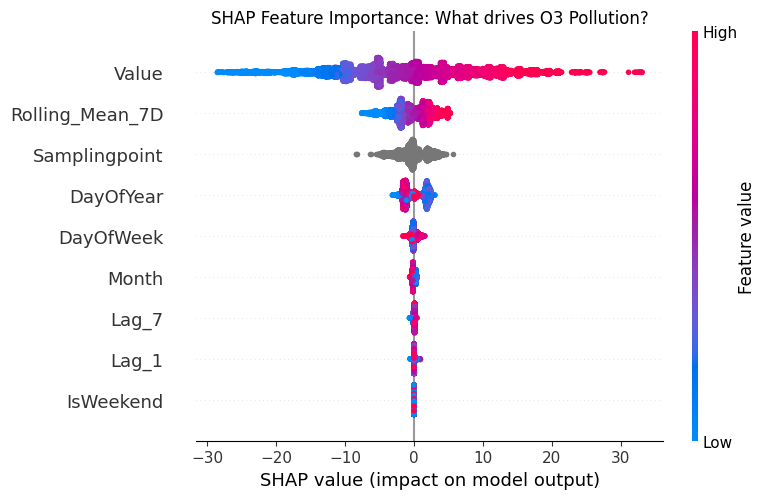

In [30]:
# Initialize the SHAP Explainer using your trained XGBoost model
explainer = shap.TreeExplainer(best_model) # For XGBoost use TreeExplaienr

shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.title(f"SHAP Feature Importance: What drives {POLLUTANT} Pollution?")
plt.tight_layout()
plt.savefig(output_dir / f"{RUN_ID}_SHAP_Feature_importance.png", bbox_inches='tight')
plt.show()

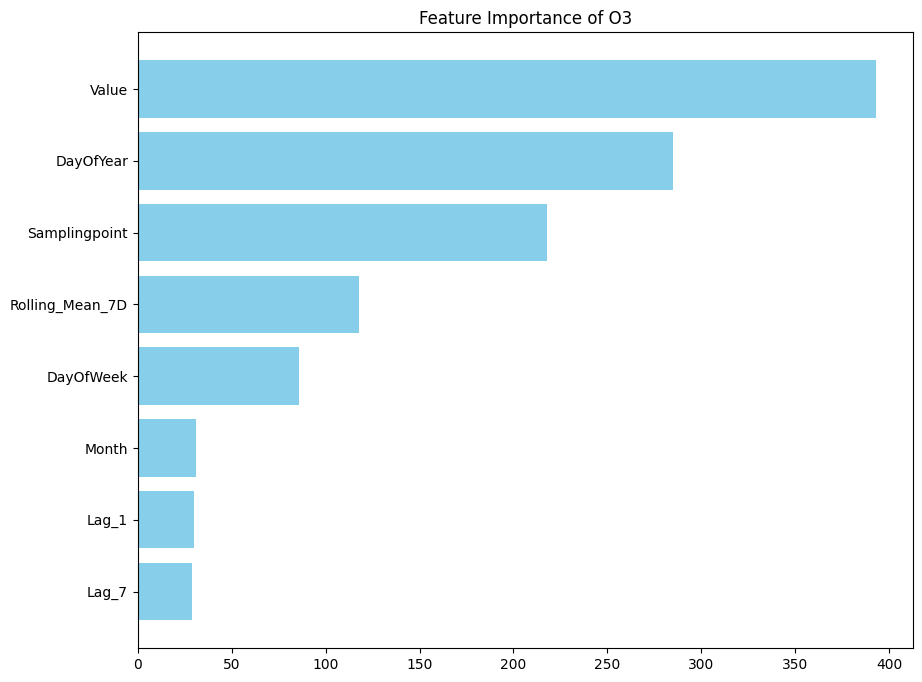

In [31]:
importance = best_model.get_booster().get_score(importance_type='weight')

importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)


top_n = 20
plt.figure(figsize=(10, 8))
plt.title(f"Feature Importance of {POLLUTANT}")
plt.barh(
    importance_df['Feature'].head(top_n)[::-1],
    importance_df['Importance'].head(top_n)[::-1],
    color='skyblue'
)
plt.savefig(output_dir / f"{RUN_ID}_Feature_Importance.png", bbox_inches='tight')

RMSE: 10.4226
MAE:  8.0336
R2:   0.6288
Samplingpoint IE/SPO.IE.IE0001RSample1_7 -> RMSE: 9.41 | MAE: 7.28 | R2: 0.50


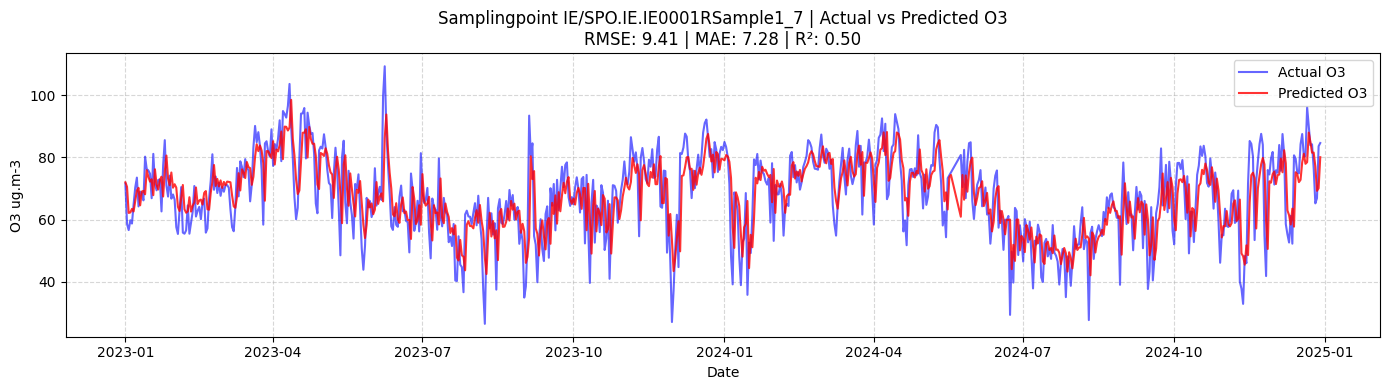

Samplingpoint IE/SPO.IE.IE027DSample2_7 -> RMSE: 10.43 | MAE: 8.05 | R2: 0.53


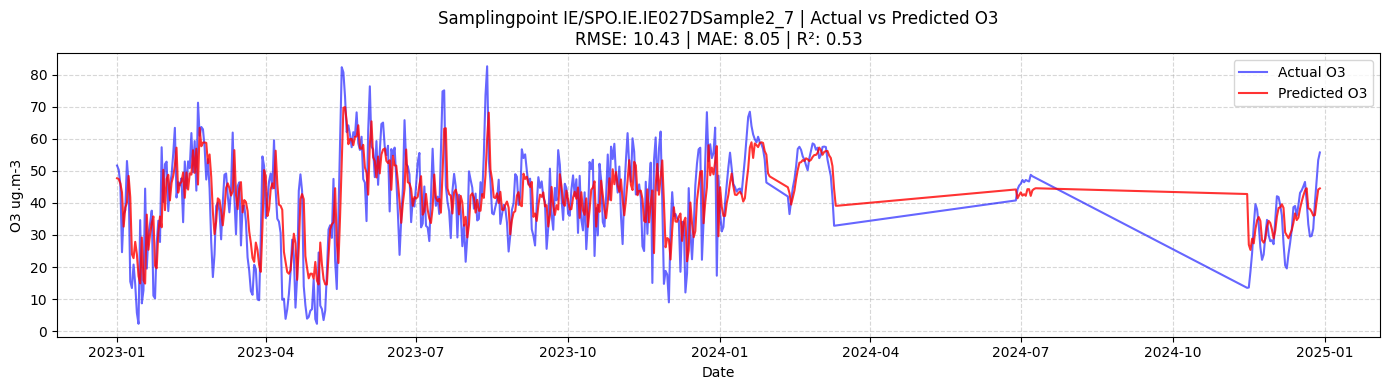

Samplingpoint IE/SPO.IE.IE0028ASample1_7 -> RMSE: 11.21 | MAE: 8.77 | R2: 0.53


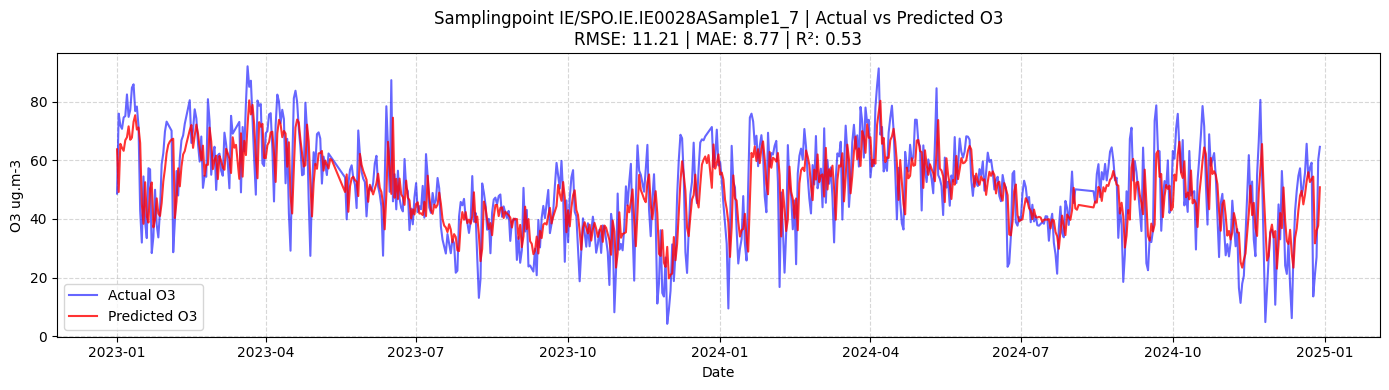

Samplingpoint IE/SPO.IE.IE0031RSample1_7 -> RMSE: 8.53 | MAE: 6.77 | R2: 0.52


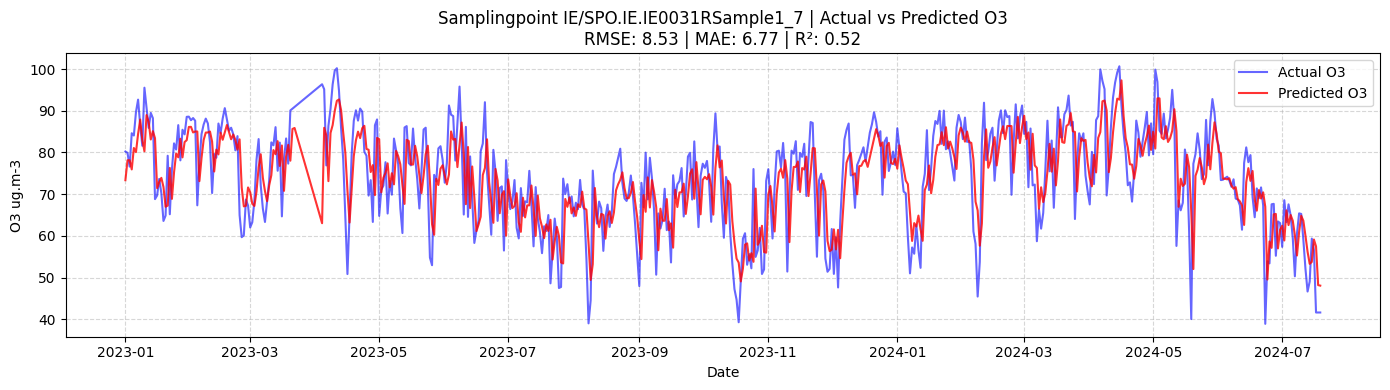

Samplingpoint IE/SPO.IE.IE003DPSample1_7 -> RMSE: 9.35 | MAE: 7.23 | R2: 0.42


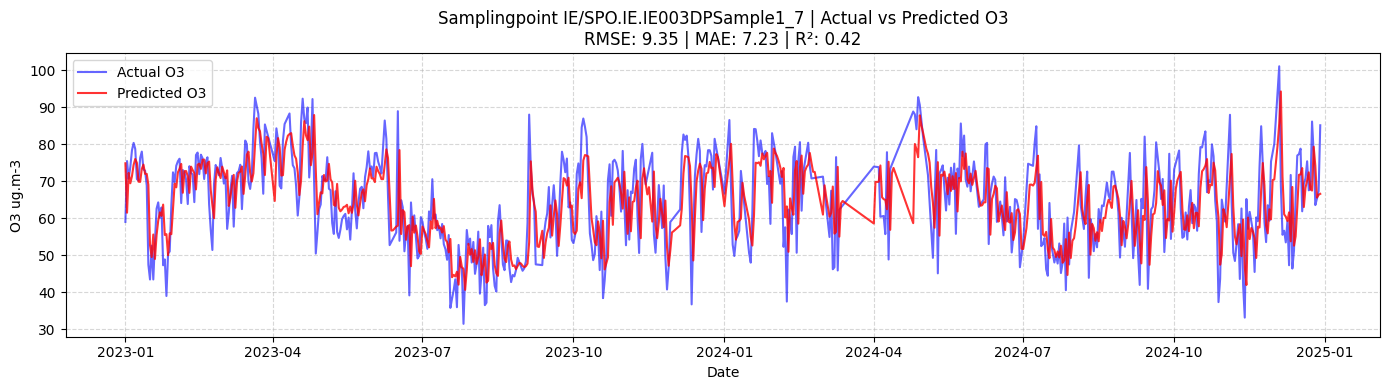

Samplingpoint IE/SPO.IE.IE004BPSample2_7 -> RMSE: 9.65 | MAE: 7.76 | R2: 0.39


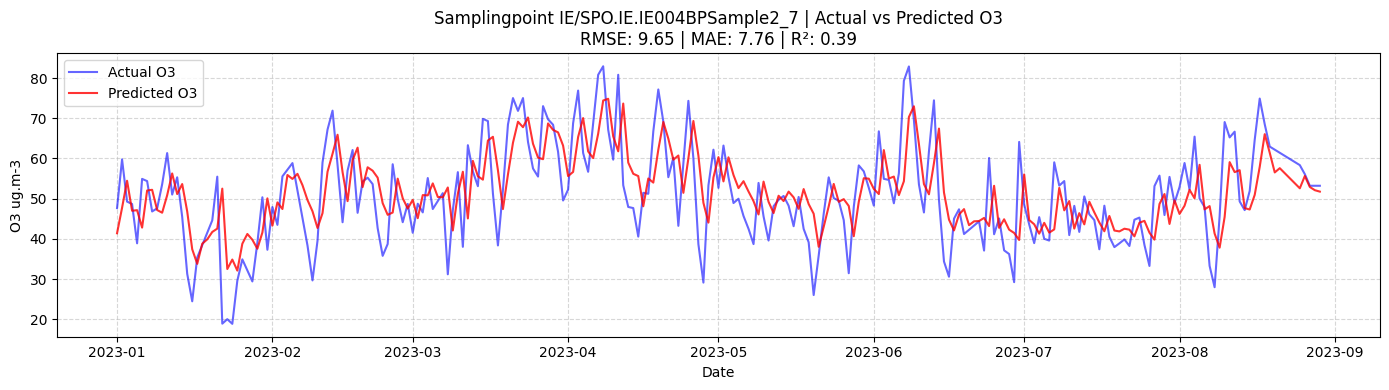

Samplingpoint IE/SPO.IE.IE005CPSample2_7 -> RMSE: 10.84 | MAE: 8.31 | R2: 0.54


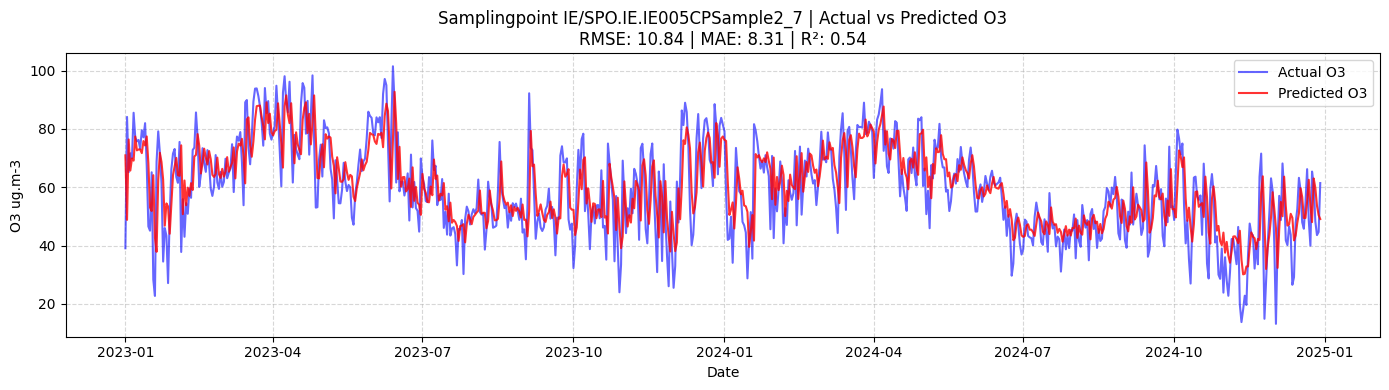

Samplingpoint IE/SPO.IE.IE0147ASample1_7 -> RMSE: 11.17 | MAE: 8.47 | R2: 0.48


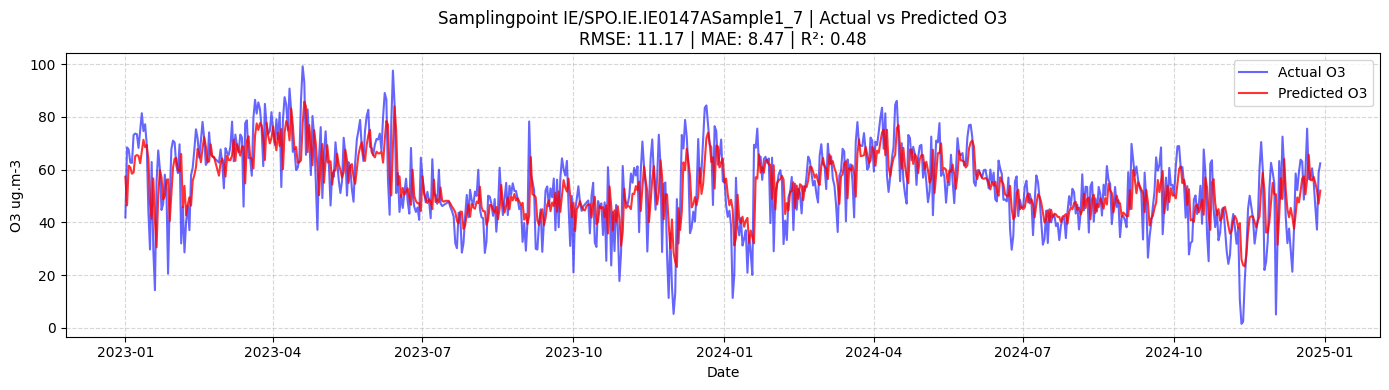

Samplingpoint IE/SPO.IE.IE006APSample1_7 -> RMSE: 10.76 | MAE: 8.43 | R2: 0.41


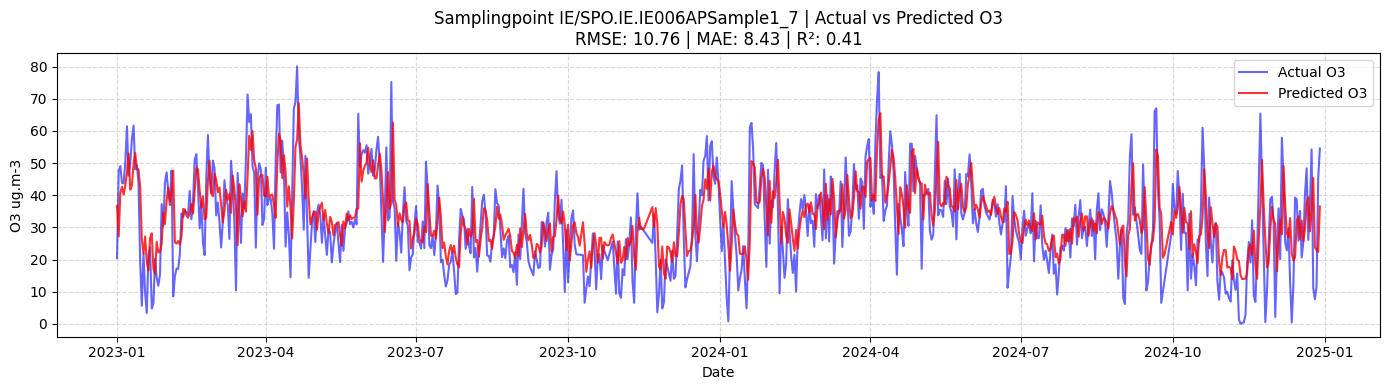

Samplingpoint IE/SPO.IE.IE007CPSample2_7 -> RMSE: 11.42 | MAE: 8.84 | R2: 0.45


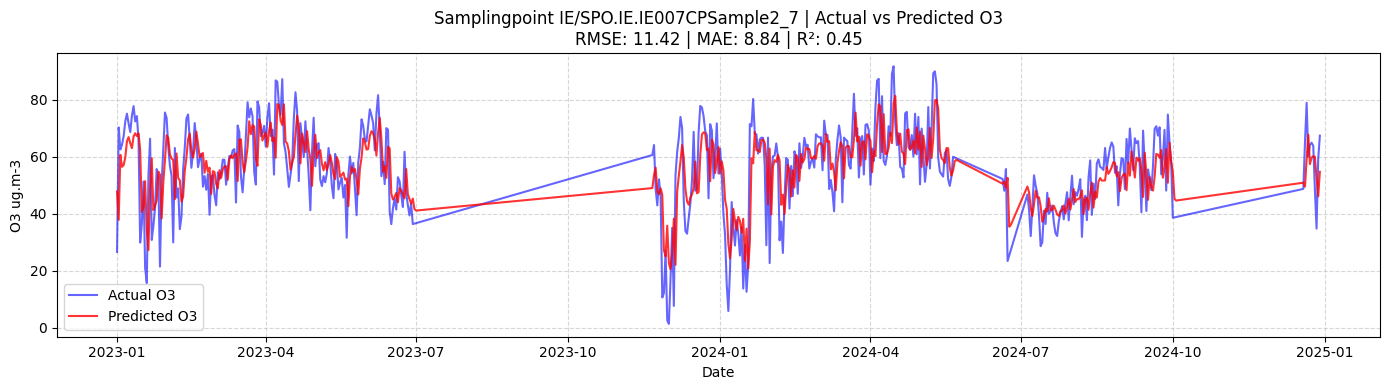

Samplingpoint IE/SPO.IE.IE0090ASample1_7 -> RMSE: 8.21 | MAE: 6.22 | R2: 0.56


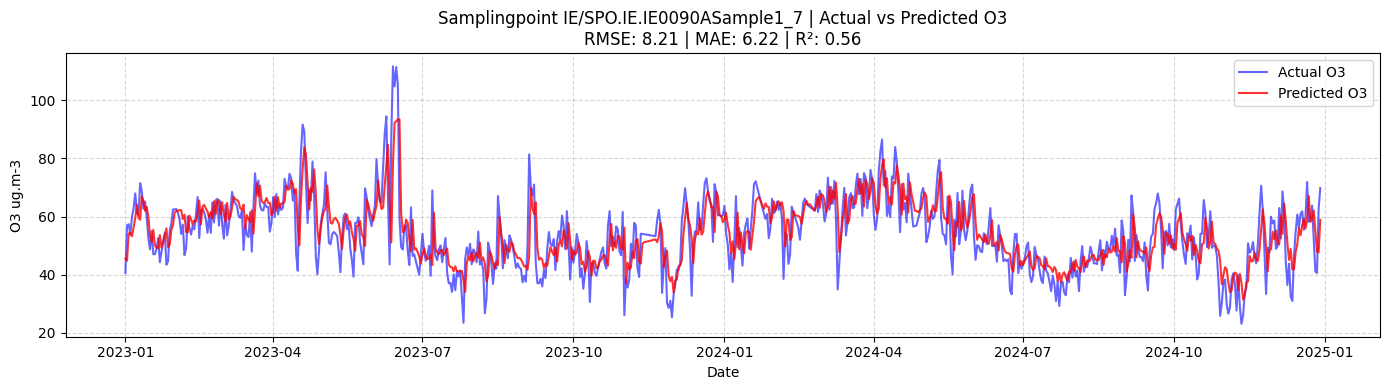

Samplingpoint IE/SPO.IE.IE0141ASample1_7 -> RMSE: 10.92 | MAE: 8.54 | R2: 0.45


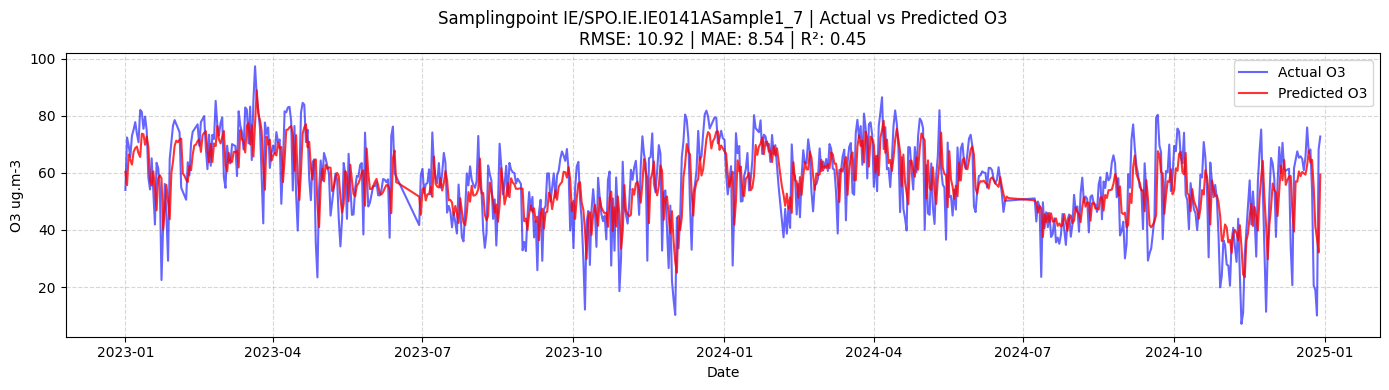

Samplingpoint IE/SPO.IE.IE010LKSample2_7 -> RMSE: 10.62 | MAE: 8.12 | R2: 0.51


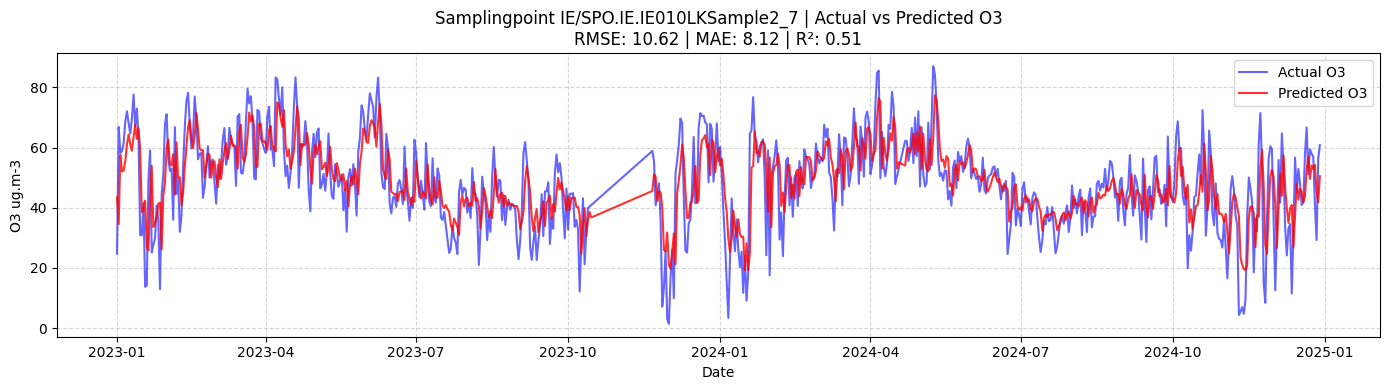

Samplingpoint IE/SPO.IE.IE0111ASample1_7 -> RMSE: 8.79 | MAE: 6.84 | R2: 0.56


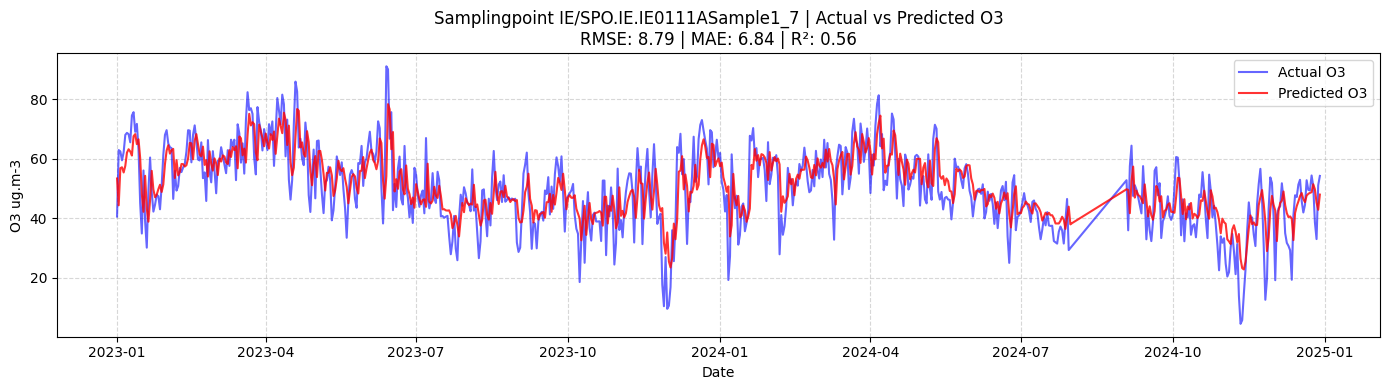

Samplingpoint IE/SPO.IE.IE0118ASample1_7 -> RMSE: 11.00 | MAE: 8.58 | R2: 0.44


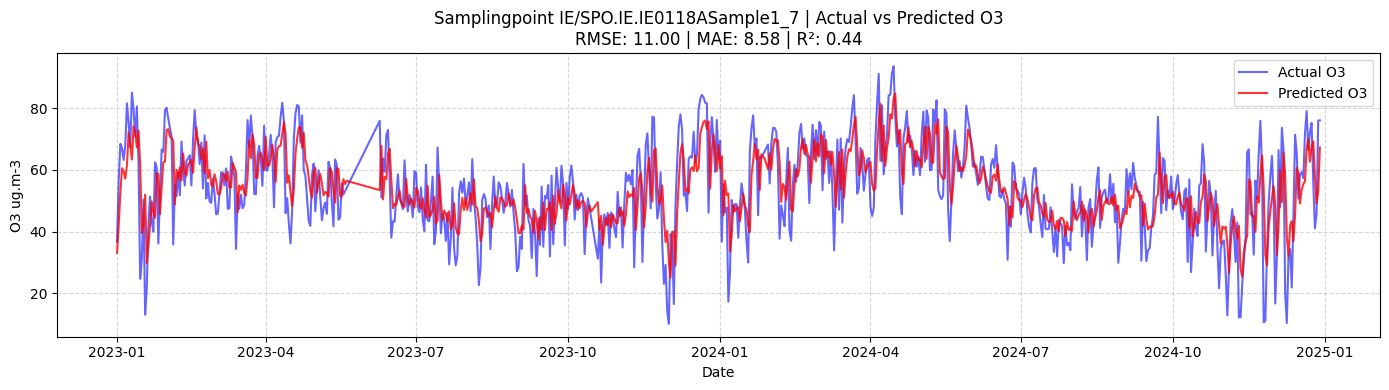

Samplingpoint IE/SPO.IE.IE0140ASample1_7 -> RMSE: 10.52 | MAE: 8.08 | R2: 0.48


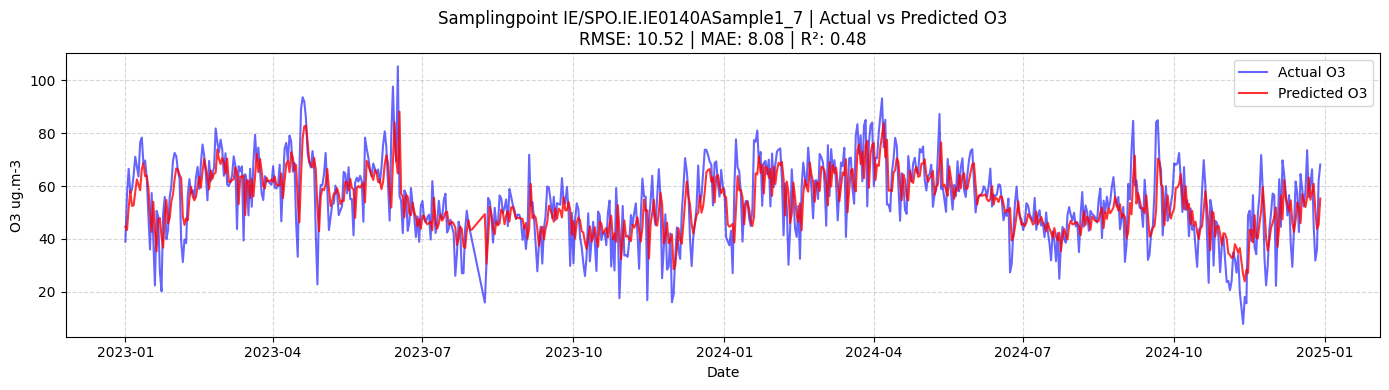

Samplingpoint IE/SPO.IE.IE001DPSample1_7 -> RMSE: 8.39 | MAE: 6.49 | R2: 0.49


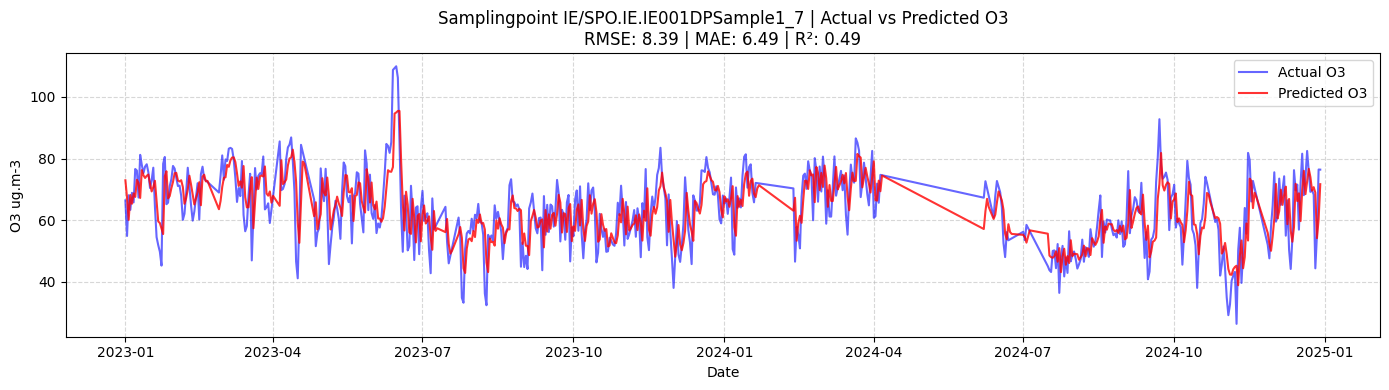

Samplingpoint IE/SPO.IE.IE0127ASample1_7 -> RMSE: 11.07 | MAE: 8.59 | R2: 0.44


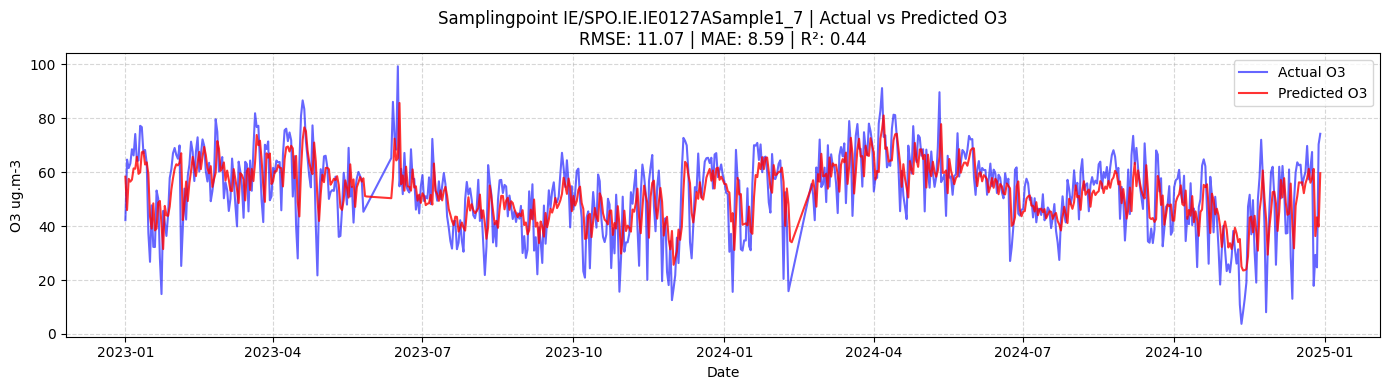

Samplingpoint IE/SPO.IE.IE012CKSample2_7 -> RMSE: 12.29 | MAE: 9.59 | R2: 0.44


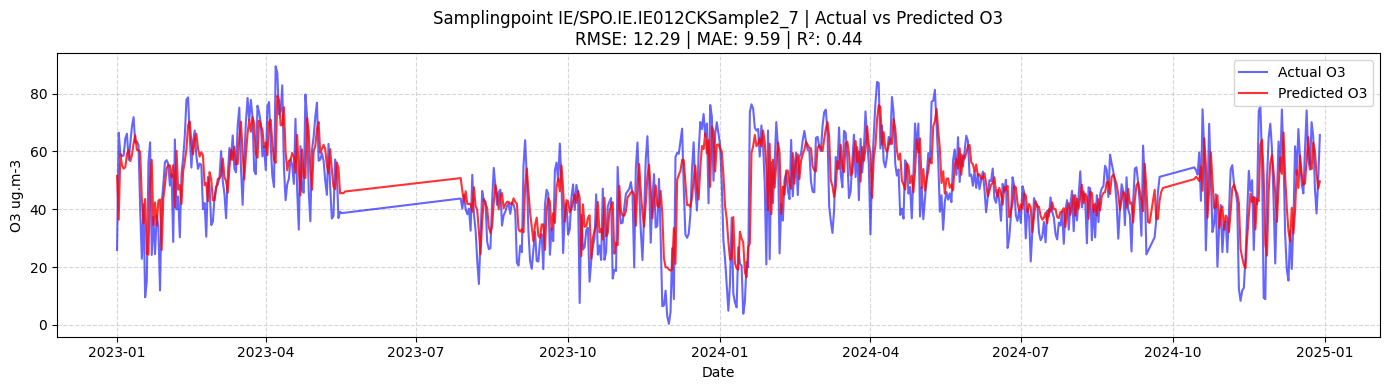

Samplingpoint IE/SPO.IE.IE013CKSample2_7 -> RMSE: 12.16 | MAE: 9.66 | R2: 0.51


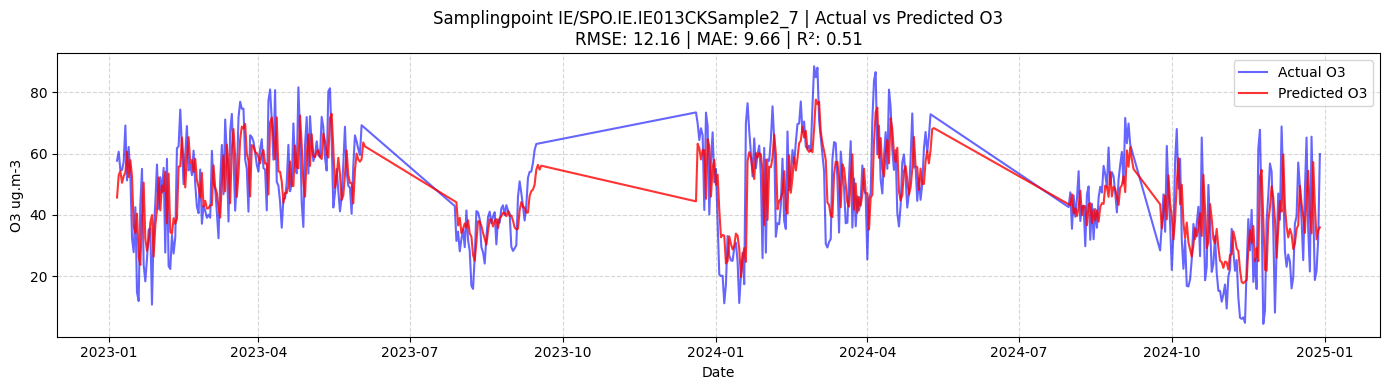

Samplingpoint IE/SPO.IE.IE001WDSample1_7 -> RMSE: 11.05 | MAE: 8.58 | R2: 0.46


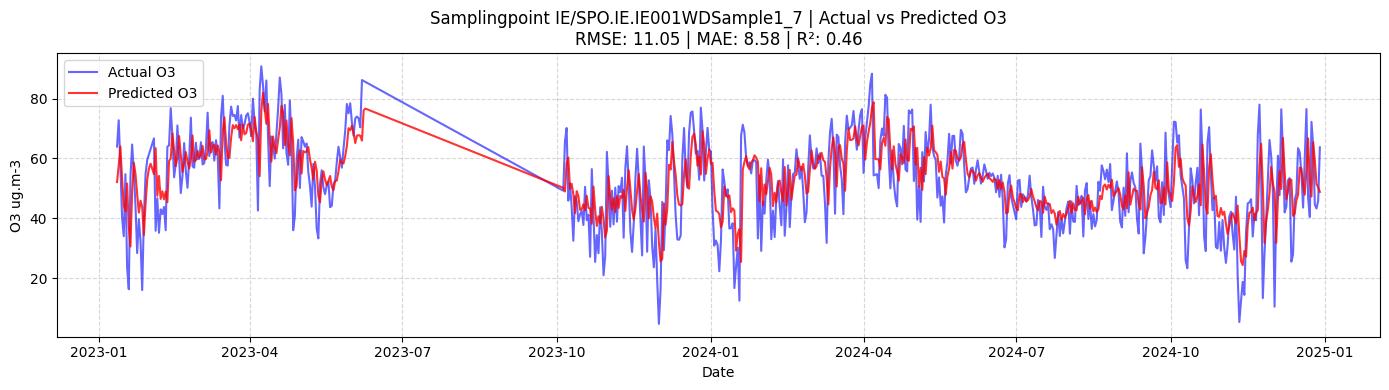

Samplingpoint IE/SPO.IE.IE001BPSample1_7 -> RMSE: 9.39 | MAE: 7.15 | R2: 0.52


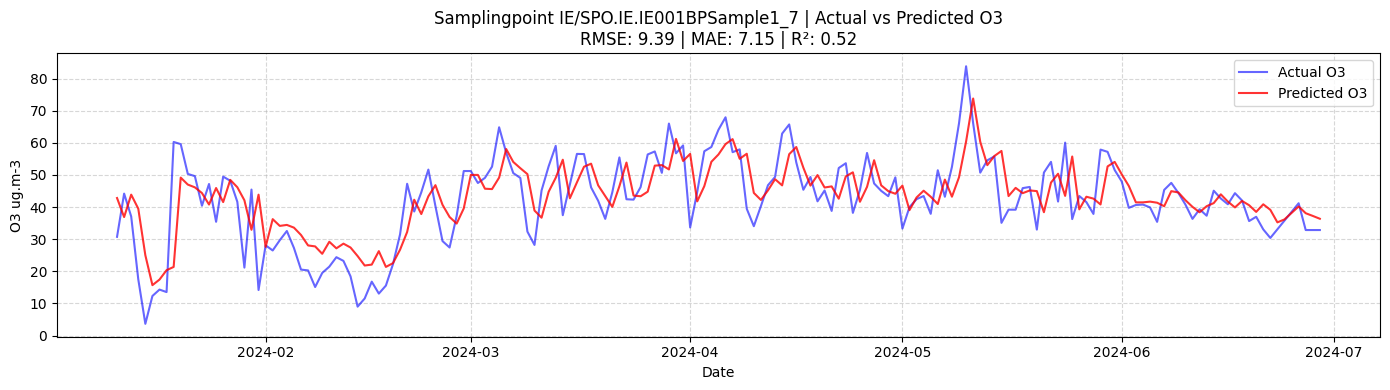

In [32]:
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R2:   {r2:.4f}")


# folder for these prediction plots
pred_plot_dir = output_dir / "Predict_vs_Actual_Plots"
pred_plot_dir.mkdir(parents=True, exist_ok=True)

# Plotting Actual vs Predicted for each station in the Test Set
results_df = test_data.copy() # already grouped staion and start (date)
results_df['Actual'] = y_test
results_df['Predicted'] = test_preds


stations = results_df['Samplingpoint'].unique() 

station_metrics_list = [] 

for station in stations:
    station_data = results_df[results_df['Samplingpoint'] == station] 
    
    # skip stations with not enough data to calculate R2 for the stations that have shut down/little test data
    if len(station_data) < 2:
        continue
        
    st_rmse = np.sqrt(mean_squared_error(station_data['Actual'], station_data['Predicted']))
    st_mae = mean_absolute_error(station_data['Actual'], station_data['Predicted'])
    st_r2 = r2_score(station_data['Actual'], station_data['Predicted'])

    station_metrics_list.append({ # add evalutation to list
        'Station': station,
        'RMSE': round(st_rmse, 3),
        'MAE': round(st_mae, 3),
        'R2': round(st_r2, 3)
    })
    
    print(f"Samplingpoint {station} -> RMSE: {st_rmse:.2f} | MAE: {st_mae:.2f} | R2: {st_r2:.2f}")
    

    plt.figure(figsize=(14, 4))
    
    # Using 'Start' for the x-axis datetime timeline
    plt.plot(station_data['Start'], station_data['Actual'], label=f'Actual {POLLUTANT}', color='blue', alpha=0.6)
    plt.plot(station_data['Start'], station_data['Predicted'], label=f'Predicted {POLLUTANT}', color='red', alpha=0.8, linewidth=1.5)
    
    plt.title(f'Samplingpoint {station} | Actual vs Predicted {POLLUTANT}\nRMSE: {st_rmse:.2f} | MAE: {st_mae:.2f} | R²: {st_r2:.2f}')
    plt.xlabel('Date')
    plt.ylabel(f'{POLLUTANT} ug.m-3')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

    clean_station_name = str(station).replace(".", "_").replace("/", "_")
    file_name = f"{COUNTRY_CODE}_{POLLUTANT}_{clean_station_name}_predict.png"
    plt.savefig(pred_plot_dir / file_name, dpi=150)

    plt.show()
    plt.close()


# list to df to csv
metrics_df = pd.DataFrame(station_metrics_list)
csv_filename = output_dir / f"{COUNTRY_CODE}_{POLLUTANT}_Every_Station_Metrics.csv"
metrics_df.to_csv(csv_filename, index=False)